In [1]:
#Célula 1
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, regexp_replace, sum, avg, count, desc, round, substring 
import matplotlib.pyplot as plt
import unicodedata
import re

In [2]:
#Célula 2
spark = SparkSession.builder\
.appName("Bolsa Familia")\
.config("spark.driver.memory", "8g") \
.config("spark.executor.memory", "8g") \
.config("spark.sql.shuffle.partitions", "50")\
.getOrCreate()

#Caminho do Arquivo

In [3]:
#Célula 3

caminho_csv ="../dados/pagamentos.csv"

df = spark.read\
.option ("header", True)\
.option ("inferSchema", True)\
.option ("sep", ";")\
.option ("encoding","ISO-8859-1")\
.csv(caminho_csv)

In [4]:
#Célula 4

df.show(5)
df.printSchema()

+---------------+--------------+---+----------------------+--------------------+--------------+--------------+--------------------+-------------+
|MÊS COMPETÊNCIA|MÊS REFERÊNCIA| UF|CÓDIGO MUNICÍPIO SIAFI|      NOME MUNICÍPIO|CPF FAVORECIDO|NIS FAVORECIDO|     NOME FAVORECIDO|VALOR PARCELA|
+---------------+--------------+---+----------------------+--------------------+--------------+--------------+--------------------+-------------+
|         202101|        202008| AM|                   205|    ATALAIA DO NORTE|***.568.112-**|   22816735078|  MARIVALDA KANAMARY|       212,00|
|         202101|        202008| AM|                   217|               BORBA|***.150.512-**|   16285415367|JUCILENE MOREIRA ...|       212,00|
|         202101|        202008| AM|                   283|SAO GABRIEL DA CA...|***.615.942-**|   13987086687|GRACIMAR BRASIL G...|       253,00|
|         202101|        202008| AP|                   613|    LARANJAL DO JARI|***.264.482-**|   12769319037|ALDENORA VIANA

In [5]:
#Célula 5

df_tratado = df

colunas_padrao = {
    "MÊS COMPETÊNCIA": "data_competencia",
    "MÊS REFERÊNCIA": "data_referencia",
    "CÓDIGO MUNICÍPIO SIAFI": "codigo_municipio",
    "UF": "uf",
    "NOME MUNICÍPIO": "nome_municipio",
    "CPF FAVORECIDO": "cpf_favorecido",
    "NIS FAVORECIDO" : "nis_favorecido",
    "NOME FAVORECIDO": "nome_favorecido",
    "VALOR PARCELA": "valor_parcela"
}

for antiga, nova in colunas_padrao.items():
    df_tratado = df_tratado.withColumnRenamed(antiga,nova)



In [6]:
#Célula 6
df_tratado.show(1)


+----------------+---------------+---+----------------+----------------+--------------+--------------+------------------+-------------+
|data_competencia|data_referencia| uf|codigo_municipio|  nome_municipio|cpf_favorecido|nis_favorecido|   nome_favorecido|valor_parcela|
+----------------+---------------+---+----------------+----------------+--------------+--------------+------------------+-------------+
|          202101|         202008| AM|             205|ATALAIA DO NORTE|***.568.112-**|   22816735078|MARIVALDA KANAMARY|       212,00|
+----------------+---------------+---+----------------+----------------+--------------+--------------+------------------+-------------+
only showing top 1 row


In [7]:
#Célula 7

df_tratado = (
    df_tratado
    .dropna()
    .withColumn(
        "valor_parcela", 
        regexp_replace(col("valor_parcela"), ",", ".").cast("decimal(10,2)")
    )
    .withColumn(
        "ano_competencia", 
        substring(col("data_competencia"), 1, 4)
    )
    .withColumn(
        "mês_competencia", 
        substring(col("data_competencia"), 5, 2)
    )
)

In [8]:
#Célula 8

df_tratado.printSchema()


root
 |-- data_competencia: integer (nullable = true)
 |-- data_referencia: integer (nullable = true)
 |-- uf: string (nullable = true)
 |-- codigo_municipio: integer (nullable = true)
 |-- nome_municipio: string (nullable = true)
 |-- cpf_favorecido: string (nullable = true)
 |-- nis_favorecido: long (nullable = true)
 |-- nome_favorecido: string (nullable = true)
 |-- valor_parcela: decimal(10,2) (nullable = true)
 |-- ano_competencia: string (nullable = true)
 |-- mês_competencia: string (nullable = true)



In [9]:
#Célula 9

df_tratado.agg(
    round(sum("valor_parcela"), 2).alias("total_pago"),
    round(avg("valor_parcela"), 2).alias("media_pagamento")
).show()

+-------------+---------------+
|   total_pago|media_pagamento|
+-------------+---------------+
|2683780840.00|         190.67|
+-------------+---------------+



In [10]:
#Célula 10

df_tratado.groupBy("uf")\
    .agg(sum("valor_parcela").alias("total_pago"))\
    .orderBy("total_pago" , ascending=False)\
    .show(5)

+---+------------+
| uf|  total_pago|
+---+------------+
| BA|342204303.00|
| SP|278566206.00|
| PE|215489490.00|
| CE|203678014.00|
| MA|201015327.00|
+---+------------+
only showing top 5 rows


In [11]:
#Célula 11

ranking_favorecido = df_tratado.groupBy("cpf_favorecido" , "nome_favorecido")\
    .agg(
        sum("valor_parcela").alias("valor_total_acumulado"),
        count("valor_parcela").alias("quantidade_parcelas")
    )\
    .orderBy(desc("valor_total_acumulado"))

In [12]:
#Célula 12
print("Rankink dos 10 primeiros com valores acumulados")
ranking_favorecido.show(5, truncate=False)

Rankink dos 10 primeiros com valores acumulados
+--------------+---------------------------------+---------------------+-------------------+
|cpf_favorecido|nome_favorecido                  |valor_total_acumulado|quantidade_parcelas|
+--------------+---------------------------------+---------------------+-------------------+
|***.615.942-**|GRACIMAR BRASIL GUERRA           |2004.00              |6                  |
|***.811.272-**|TARCILA MELO OLIVEIRA            |1782.00              |1                  |
|***.600.238-**|CRISTIANE FERNANDES DA SILVA     |1518.00              |6                  |
|***.688.373-**|ANTONIA ALVES SOUSA              |1514.00              |1                  |
|***.756.192-**|MARIA DE FATIMA MARTINS DE CASTRO|1514.00              |1                  |
+--------------+---------------------------------+---------------------+-------------------+
only showing top 5 rows


In [13]:
#Célula 13

media_geral = df_tratado.agg(avg("valor_parcela")).collect()[0][0]
print(f"Para fins de comparação, media geral de cada parcela e R$ {media_geral:.2f}")

Para fins de comparação, media geral de cada parcela e R$ 190.67


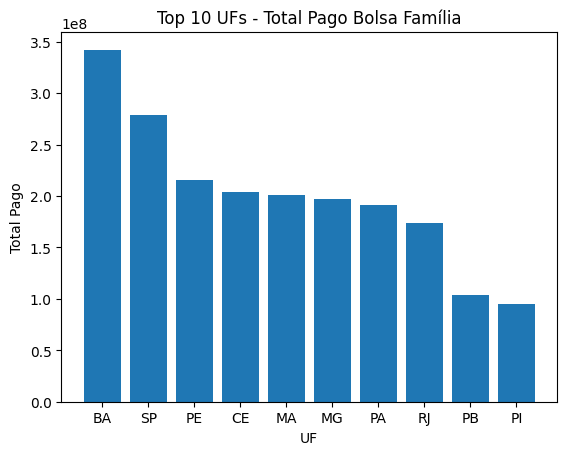

In [14]:
df_uf = df_tratado.groupBy("uf") \
    .agg(sum("valor_parcela").alias("total_pago")) \
    .orderBy("total_pago", ascending=False) \
    .limit(10) \
    .toPandas()

# Gráfico
plt.figure()
plt.bar(df_uf["uf"], df_uf["total_pago"])
plt.title("Top 10 UFs - Total Pago Bolsa Família")
plt.xlabel("UF")
plt.ylabel("Total Pago")
plt.show()